In [10]:
import os

In [11]:
os.getcwd()

'C:\\Users\\vidya\\diabetes_project'

In [12]:
import pandas as pd

In [13]:
demo=pd.read_sas("raw_data/2007_08/DEMO_E.xpt",format='xport')

In [14]:
os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'diabetes.ipynb',
 'Figure2_Temporal_Calibration.pdf',
 'Figure2_Temporal_Calibration.png',
 'Figure2_Temporal_Calibration.tiff',
 'raw_data',
 'Untitled.ipynb']

In [15]:
import os
os.listdir("raw_data")

['.ipynb_checkpoints',
 '2007_08',
 '2009_10',
 '2011_12',
 '2013_14',
 '2015_16',
 '2017_18']

In [16]:
os.listdir("raw_data/2007_08")

['.ipynb_checkpoints',
 'BMX_E.xpt',
 'BPX_E.xpt',
 'DEMO_E.xpt',
 'DIQ_E.xpt',
 'GHB_E.xpt',
 'GLU_E.xpt']

In [17]:
demo = pd.read_sas("raw_data/2007_08/DEMO_E.xpt", format="xport")
bmx  = pd.read_sas("raw_data/2007_08/BMX_E.xpt", format="xport")
bpx  = pd.read_sas("raw_data/2007_08/BPX_E.xpt", format="xport")
ghb  = pd.read_sas("raw_data/2007_08/GHB_E.xpt", format="xport")
glu  = pd.read_sas("raw_data/2007_08/GLU_E.xpt", format="xport")
diq  = pd.read_sas("raw_data/2007_08/DIQ_E.xpt", format="xport")

In [18]:
demo.shape

(10149, 43)

In [19]:
bmx.shape

(9762, 23)

In [20]:
bpx.shape

(9762, 27)

In [21]:
ghb.shape

(6917, 2)

In [22]:
glu.shape

(3315, 8)

In [23]:
diq.shape

(9666, 36)

In [24]:
demo.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANG,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA
0,41475.0,5.0,2.0,2.0,2.0,62.0,751.0,752.0,5.0,2.0,...,2.0,2.0,1.0,2.0,2.0,1.0,59356.356426,60045.772497,1.0,60.0
1,41476.0,5.0,2.0,1.0,2.0,6.0,81.0,82.0,5.0,NaN,...,2.0,2.0,NaN,NaN,NaN,NaN,35057.218405,35353.210440,1.0,70.0
2,41477.0,5.0,2.0,2.0,1.0,71.0,859.0,860.0,3.0,1.0,...,2.0,2.0,1.0,2.0,2.0,1.0,9935.266183,10074.150074,1.0,67.0
3,41478.0,5.0,2.0,2.0,2.0,1.0,17.0,17.0,3.0,NaN,...,2.0,2.0,NaN,NaN,NaN,NaN,12846.712058,14560.472652,2.0,59.0
4,41479.0,5.0,2.0,1.0,1.0,52.0,629.0,630.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,8727.797555,9234.055759,1.0,70.0


## Confirm ID Column Exists in All Files

In [25]:
for df,name in zip([demo,bmx,bpx,ghb,glu,diq],
                  ["demo","bmx","bpx","glu","diq"]):
    print(name,"SEQN" in df.columns)

demo True
bmx True
bpx True
glu True
diq True


In [26]:
demo.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR',
       'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'DMQMILIT', 'DMDBORN2', 'DMDCITZN',
       'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ',
       'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'RIDEXPRG', 'DMDHRGND',
       'DMDHRAGE', 'DMDHRBR2', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'SIALANG',
       'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG',
       'MIAPROXY', 'MIAINTRP', 'AIALANG', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU',
       'SDMVSTRA'],
      dtype='object')

In [27]:
ghb.columns

Index(['SEQN', 'LBXGH'], dtype='object')

In [28]:
glu.columns

Index(['SEQN', 'WTSAF2YR', 'LBXGLU', 'LBDGLUSI', 'LBXIN', 'LBDINSI',
       'PHAFSTHR', 'PHAFSTMN'],
      dtype='object')

# Merge the Datasets (2007–2008 Only)

In [29]:
df=demo.merge(bmx,on='SEQN',how="left")

In [30]:
df = df.merge(bpx, on="SEQN", how="left")

In [31]:
df = df.merge(ghb, on="SEQN", how="left")
df = df.merge(glu, on="SEQN", how="left")
df = df.merge(diq, on="SEQN", how="left")

In [32]:
df.shape

(10149, 134)

In [33]:
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,DIQ300D,DID310S,DID310D,DID320,DID330,DID340,DID350,DIQ350U,DIQ360,DIQ080
0,41475.0,5.0,2.0,2.0,2.0,62.0,751.0,752.0,5.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,41476.0,5.0,2.0,1.0,2.0,6.0,81.0,82.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,41477.0,5.0,2.0,2.0,1.0,71.0,859.0,860.0,3.0,1.0,...,9999.0,6666.0,6666.0,9999.0,6666.0,1.0,7.0,2.0,2.0,2.0
3,41478.0,5.0,2.0,2.0,2.0,1.0,17.0,17.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,41479.0,5.0,2.0,1.0,1.0,52.0,629.0,630.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df[['RIDAGEYR', 'RIAGENDR', 'LBXGH', 'LBXGLU']].head()

,RIDAGEYR,RIAGENDR,LBXGH,LBXGLU
0,62.0,2.0,5.7,NaN
1,6.0,2.0,NaN,NaN
2,71.0,1.0,9.5,NaN
3,1.0,2.0,NaN,NaN
4,52.0,1.0,5.7,113.0


In [35]:
df[['DIQ010']].value_counts(dropna=False)

DIQ010
2.0       8774
1.0        777
NaN        483
3.0        106
9.0          9
Name: count, dtype: int64

# Create Diabetes Outcome Variable

In [36]:
import numpy as np

df["diabetes"] = np.where(
    (df["LBXGH"] >= 6.5) |
    (df["LBXGLU"] >= 126) |
    (df["DIQ010"] == 1),
    1, 0
)

In [37]:
df["diabetes"].value_counts()

diabetes
0    9092
1    1057
Name: count, dtype: int64

In [38]:
df["diabetes"].mean()

np.float64(0.10414819194009262)

# Restrict to Adults

In [39]:
df = df[df["RIDAGEYR"] >= 18]
df.shape

(6228, 135)

In [40]:
df["diabetes"].value_counts()
df["diabetes"].mean()

np.float64(0.16650610147719974)

# Create Modeling Dataset

In [41]:
features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "BMXBMI",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH"
]

model_df = df[features + ["diabetes", "WTMEC2YR"]].copy()
model_df.shape

(6228, 11)

In [42]:
model_df.isna().sum()

RIDAGEYR       0
RIAGENDR       0
RIDRETH1       0
INDFMPIR     592
BMXBMI       344
BPXSY1       681
BPXDI1       681
LBXGLU      3476
LBXGH        618
diabetes       0
WTMEC2YR       0
dtype: int64

# We REMOVE fasting glucose (LBXGLU).

# We keep:

# HbA1c (LBXGH)

# BMI

# BP

# Demographics

In [43]:
features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "BMXBMI",
    "BPXSY1",
    "BPXDI1",
    "LBXGH"
]

model_df = df[features + ["diabetes", "WTMEC2YR"]].copy()

model_df.isna().sum()

RIDAGEYR      0
RIAGENDR      0
RIDRETH1      0
INDFMPIR    592
BMXBMI      344
BPXSY1      681
BPXDI1      681
LBXGH       618
diabetes      0
WTMEC2YR      0
dtype: int64

In [44]:
# Separate features and target
X = model_df.drop(columns=["diabetes"])
y = model_df["diabetes"]

# Median imputation
X_imputed = X.fillna(X.median())

# Check remaining missing
X_imputed.isna().sum()

RIDAGEYR    0
RIAGENDR    0
RIDRETH1    0
INDFMPIR    0
BMXBMI      0
BPXSY1      0
BPXDI1      0
LBXGH       0
WTMEC2YR    0
dtype: int64

In [45]:
# Separate survey weights
weights = X_imputed["WTMEC2YR"]

# Remove weight from feature matrix
X_imputed = X_imputed.drop(columns=["WTMEC2YR"])

# Convert categorical variables to category type
X_imputed["RIAGENDR"] = X_imputed["RIAGENDR"].astype("category")
X_imputed["RIDRETH1"] = X_imputed["RIDRETH1"].astype("category")

# One-hot encoding
X_encoded = pd.get_dummies(X_imputed, drop_first=True)

X_encoded.shape


(6228, 11)

# Train/Test Split (Temporal Later, Random Now)

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
!pip install scikit-learn

In [48]:
import sys
print(sys.executable)

C:\Users\vidya\AppData\Local\Programs\Python\Python312\python.exe


In [49]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_encoded,
    y,
    weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((4982, 11), (1246, 11))

In [54]:
X_encoded.shape

(6228, 11)

In [55]:
X_encoded.shape

(6228, 11)

# Train/Test Split

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_encoded,
    y,
    weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
print(X_train.shape)
print(X_test.shape)

(4982, 11)
(1246, 11)


# Weighted Logistic Regression (Baseline Model)

In [59]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Fit with survey weights
log_model.fit(X_train, y_train, sample_weight=w_train)

# Predict probabilities
y_pred_proba = log_model.predict_proba(X_test)[:, 1]


# Evaluate AUROC (Weighted)

In [60]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba, sample_weight=w_test)
print("Weighted AUROC:", auc)

Weighted AUROC: 0.9341096417867021


# Compute Weighted Brier Score

In [61]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_pred_proba, sample_weight=w_test)
print("Weighted Brier Score:", brier)

Weighted Brier Score: 0.03596951227508065


In [62]:
print("Mean predicted probability:", y_pred_proba.mean())
print("Observed prevalence:", y_test.mean())

Mean predicted probability: 0.15512361937635255
Observed prevalence: 0.16613162118780098


# Calibration Slope & Intercept

In [63]:
import statsmodels.api as sm

# Avoid 0 or 1 probabilities
eps = 1e-6
p = np.clip(y_pred_proba, eps, 1 - eps)

# Logit of predicted probability
logit_p = np.log(p / (1 - p))

# Fit logistic recalibration model
X_cal = sm.add_constant(logit_p)
cal_model = sm.GLM(y_test, X_cal, 
                   family=sm.families.Binomial(),
                   freq_weights=w_test)

cal_result = cal_model.fit()

print(cal_result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 1246
Model:                            GLM   Df Residuals:              44337930.45
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.3668e+06
Date:                Mon, 02 Mar 2026   Deviance:                   1.2734e+07
Time:                        14:09:10   Pearson chi2:                 7.13e+07
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0710      0.001    -70.091      0.0

In [64]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


# generate calibration curve.

In [65]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

In [66]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_proba,
    n_bins=10,
    strategy="quantile"
)

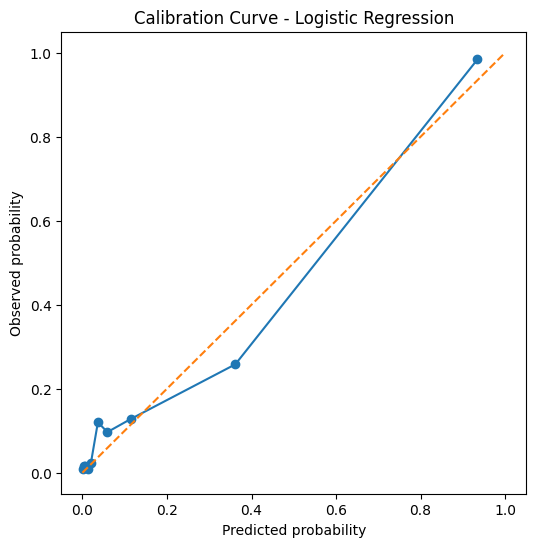

In [67]:
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration Curve - Logistic Regression")
plt.show()

# XGBoost Baseline:train a nonlinear model and compare.

In [68]:
!pip install xgboost

# Train Weighted XGBoost

In [69]:
from xgboost import XGBClassifier

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

# Fit with survey weights
xgb_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

# Predict probabilities
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]


C:\Users\vidya\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:09:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [70]:
import sys
!{sys.executable} -m pip install xgboost



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [71]:
from xgboost import XGBClassifier

In [72]:
print("XGBoost Weighted AUROC:", auc_xgb)
print("XGBoost Weighted Brier:", brier_xgb)

NameError: name 'auc_xgb' is not defined

In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss

auc_xgb = roc_auc_score(y_test, y_pred_xgb, sample_weight=w_test)
brier_xgb = brier_score_loss(y_test, y_pred_xgb, sample_weight=w_test)

print("XGBoost Weighted AUROC:", auc_xgb)
print("XGBoost Weighted Brier:", brier_xgb)


In [ ]:
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calibration of XGBoost

In [ ]:
import statsmodels.api as sm
import numpy as np

eps = 1e-6
p_xgb = np.clip(y_pred_xgb, eps, 1 - eps)
logit_p_xgb = np.log(p_xgb / (1 - p_xgb))

X_cal_xgb = sm.add_constant(logit_p_xgb)
cal_model_xgb = sm.GLM(
    y_test,
    X_cal_xgb,
    family=sm.families.Binomial(),
    freq_weights=w_test
)

cal_result_xgb = cal_model_xgb.fit()
print(cal_result_xgb.summary())

# Reliability Curve for XGBoost

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test,
    y_pred_xgb,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label="XGBoost")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration Curve - XGBoost")
plt.legend()
plt.show()

# Apply Isotonic Calibration

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Create new XGBoost model (fresh)
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Wrap with isotonic calibration
xgb_calibrated = CalibratedClassifierCV(
    xgb_base,
    method="isotonic",
    cv=5
)

# Fit with weights
xgb_calibrated.fit(X_train, y_train, sample_weight=w_train)

# Predict calibrated probabilities
y_pred_xgb_iso = xgb_calibrated.predict_proba(X_test)[:, 1]

In [ ]:
auc_xgb_iso = roc_auc_score(y_test, y_pred_xgb_iso, sample_weight=w_test)
brier_xgb_iso = brier_score_loss(y_test, y_pred_xgb_iso, sample_weight=w_test)

print("Isotonic XGBoost AUROC:", auc_xgb_iso)
print("Isotonic XGBoost Brier:", brier_xgb_iso)

# Compute Slope for Isotonic Model

In [ ]:
eps = 1e-6
p_iso = np.clip(y_pred_xgb_iso, eps, 1 - eps)
logit_p_iso = np.log(p_iso / (1 - p_iso))

X_cal_iso = sm.add_constant(logit_p_iso)

cal_model_iso = sm.GLM(
    y_test,
    X_cal_iso,
    family=sm.families.Binomial(),
    freq_weights=w_test
)

cal_result_iso = cal_model_iso.fit()
print(cal_result_iso.summary())

# Compute Expected Calibration Error (ECE)

In [ ]:
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    ece = 0.0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            bin_acc = np.mean(y_true[mask])
            bin_conf = np.mean(y_prob[mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(mask) / len(y_true)
    return ece

ece_log = compute_ece(y_test.values, y_pred_proba)
ece_xgb = compute_ece(y_test.values, y_pred_xgb)
ece_xgb_iso = compute_ece(y_test.values, y_pred_xgb_iso)

print("ECE Logistic:", ece_log)
print("ECE XGB:", ece_xgb)
print("ECE XGB Isotonic:", ece_xgb_iso)

# Proceed with loading 2009–2010 files

In [77]:
demo_f = pd.read_sas("raw_data/2009_10/DEMO_F.xpt", format="xport")

In [78]:
bmx_f  = pd.read_sas("raw_data/2009_10/BMX_F.xpt", format="xport")
bpx_f  = pd.read_sas("raw_data/2009_10/BPX_F.xpt", format="xport")
ghb_f  = pd.read_sas("raw_data/2009_10/GHB_F.xpt", format="xport")
glu_f  = pd.read_sas("raw_data/2009_10/GLU_F.xpt", format="xport")
diq_f  = pd.read_sas("raw_data/2009_10/DIQ_F.xpt", format="xport")

# Merge 2009–2010

In [79]:
df_f = demo_f.merge(bmx_f, on="SEQN", how="left")
df_f = df_f.merge(bpx_f, on="SEQN", how="left")
df_f = df_f.merge(ghb_f, on="SEQN", how="left")
df_f = df_f.merge(glu_f, on="SEQN", how="left")
df_f = df_f.merge(diq_f, on="SEQN", how="left")

df_f.shape

(10537, 118)

# Restrict to Adults

In [80]:
df_f = df_f[df_f["RIDAGEYR"] >= 18]
df_f.shape

(6527, 118)

# Create Diabetes Outcome

In [81]:
df_f["diabetes"] = np.where(
    (df_f["LBXGH"] >= 6.5) |
    (df_f["LBXGLU"] >= 126) |
    (df_f["DIQ010"] == 1),
    1, 0
)

# Create SAME Feature Set

In [82]:
features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "BMXBMI",
    "BPXSY1",
    "BPXDI1",
    "LBXGH"
]

model_df_f = df_f[features + ["diabetes", "WTMEC2YR"]].copy()

model_df_f.shape

(6527, 10)

# Use Training Medians:impute 2009–2010 using medians from 2007–2008, not its own medians.

# Recompute Training Medians

In [74]:
# Recreate original training feature set (before encoding)
train_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "BMXBMI",
    "BPXSY1",
    "BPXDI1",
    "LBXGH",
    "WTMEC2YR"
]

train_original = df[df["RIDAGEYR"] >= 18][train_features].copy()

train_medians = train_original.median()

train_medians

RIDAGEYR       49.000000
RIAGENDR        2.000000
RIDRETH1        3.000000
INDFMPIR        2.040000
BMXBMI         27.815000
BPXSY1        122.000000
BPXDI1         70.000000
LBXGH           5.500000
WTMEC2YR    25442.570522
dtype: float64

# Impute 2009–2010 Using Training Medians

In [84]:
X_f = model_df_f.drop(columns=["diabetes"])

# Apply training medians (important: from 2007–08)
X_f = X_f.fillna(train_medians)

y_f = model_df_f["diabetes"]
w_f = X_f["WTMEC2YR"]

# Remove weight from predictors
X_f = X_f.drop(columns=["WTMEC2YR"])

# Encode Categorical Variables

In [85]:
X_f["RIAGENDR"] = X_f["RIAGENDR"].astype("category")
X_f["RIDRETH1"] = X_f["RIDRETH1"].astype("category")

X_f_encoded = pd.get_dummies(X_f, drop_first=True)

X_f_encoded.shape

(6527, 11)

# Align Columns with Training Data

In [86]:
# Ensure same column order as training
X_f_encoded = X_f_encoded.reindex(columns=X_encoded.columns, fill_value=0)

X_f_encoded.shape

(6527, 11)

# External Validation⃣ Logistic Regression (External)

In [87]:
from sklearn.metrics import roc_auc_score, brier_score_loss

y_pred_log_ext = log_model.predict_proba(X_f_encoded)[:, 1]

auc_log_ext = roc_auc_score(y_f, y_pred_log_ext, sample_weight=w_f)
brier_log_ext = brier_score_loss(y_f, y_pred_log_ext, sample_weight=w_f)

print("External Logistic AUROC:", auc_log_ext)
print("External Logistic Brier:", brier_log_ext)

External Logistic AUROC: 0.9408319881456157
External Logistic Brier: 0.03735857588946031


In [88]:
X_f_encoded.isna().sum()

RIDAGEYR        0
INDFMPIR        0
BMXBMI          0
BPXSY1          0
BPXDI1          0
LBXGH           0
RIAGENDR_2.0    0
RIDRETH1_2.0    0
RIDRETH1_3.0    0
RIDRETH1_4.0    0
RIDRETH1_5.0    0
dtype: int64

# External XGBoost Evaluation

In [89]:
y_pred_xgb_ext = xgb_model.predict_proba(X_f_encoded)[:, 1]

auc_xgb_ext = roc_auc_score(y_f, y_pred_xgb_ext, sample_weight=w_f)
brier_xgb_ext = brier_score_loss(y_f, y_pred_xgb_ext, sample_weight=w_f)

print("External XGB AUROC:", auc_xgb_ext)
print("External XGB Brier:", brier_xgb_ext)

External XGB AUROC: 0.9465636906367867
External XGB Brier: 0.03508902399175609


# External Calibration Slope (Logistic)

In [90]:
eps = 1e-6
p_log_ext = np.clip(y_pred_log_ext, eps, 1 - eps)
logit_log_ext = np.log(p_log_ext / (1 - p_log_ext))

X_cal_log_ext = sm.add_constant(logit_log_ext)

cal_model_log_ext = sm.GLM(
    y_f,
    X_cal_log_ext,
    family=sm.families.Binomial(),
    freq_weights=w_f
)

cal_result_log_ext = cal_model_log_ext.fit()
print(cal_result_log_ext.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 6527
Model:                            GLM   Df Residuals:             226243350.61
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.2585e+07
Date:                Thu, 19 Feb 2026   Deviance:                   6.5169e+07
Time:                        12:10:42   Pearson chi2:                 6.76e+08
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2225      0.000   -540.283      0.0

# External Calibration for XGBoost

In [91]:
eps = 1e-6
p_xgb_ext = np.clip(y_pred_xgb_ext, eps, 1 - eps)
logit_xgb_ext = np.log(p_xgb_ext / (1 - p_xgb_ext))

X_cal_xgb_ext = sm.add_constant(logit_xgb_ext)

cal_model_xgb_ext = sm.GLM(
    y_f,
    X_cal_xgb_ext,
    family=sm.families.Binomial(),
    freq_weights=w_f
)

cal_result_xgb_ext = cal_model_xgb_ext.fit()
print(cal_result_xgb_ext.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 6527
Model:                            GLM   Df Residuals:             226243350.61
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.9858e+07
Date:                Thu, 19 Feb 2026   Deviance:                   5.9716e+07
Time:                        12:15:51   Pearson chi2:                 2.55e+08
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3353      0.001   -649.970      0.0

# Decision Curve Analysis (DCA)

# Internal DCA (2007–08 Test Set)

In [92]:
import numpy as np

def decision_curve(y_true, y_prob, thresholds, sample_weight=None):
    N = len(y_true)
    net_benefits = []
    
    for pt in thresholds:
        preds = (y_prob >= pt).astype(int)
        
        if sample_weight is not None:
            TP = np.sum(sample_weight[(preds == 1) & (y_true == 1)])
            FP = np.sum(sample_weight[(preds == 1) & (y_true == 0)])
            total_weight = np.sum(sample_weight)
        else:
            TP = np.sum((preds == 1) & (y_true == 1))
            FP = np.sum((preds == 1) & (y_true == 0))
            total_weight = N
        
        NB = (TP / total_weight) - (FP / total_weight) * (pt / (1 - pt))
        net_benefits.append(NB)
        
    return np.array(net_benefits)

In [93]:
thresholds = np.linspace(0.01, 0.5, 50)

nb_log_int = decision_curve(y_test.values, y_pred_proba, thresholds, w_test.values)
nb_xgb_int = decision_curve(y_test.values, y_pred_xgb, thresholds, w_test.values)

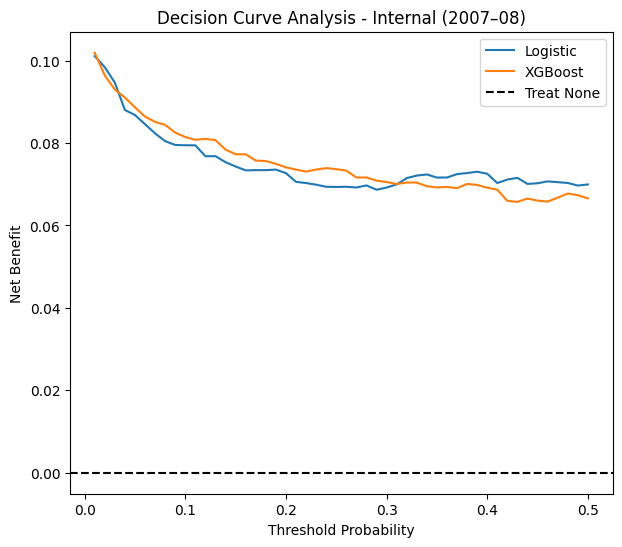

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.plot(thresholds, nb_log_int, label="Logistic")
plt.plot(thresholds, nb_xgb_int, label="XGBoost")
plt.axhline(0, linestyle='--', color='black', label="Treat None")

plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis - Internal (2007–08)")
plt.legend()
plt.show()

# External DCA (2009–2010)

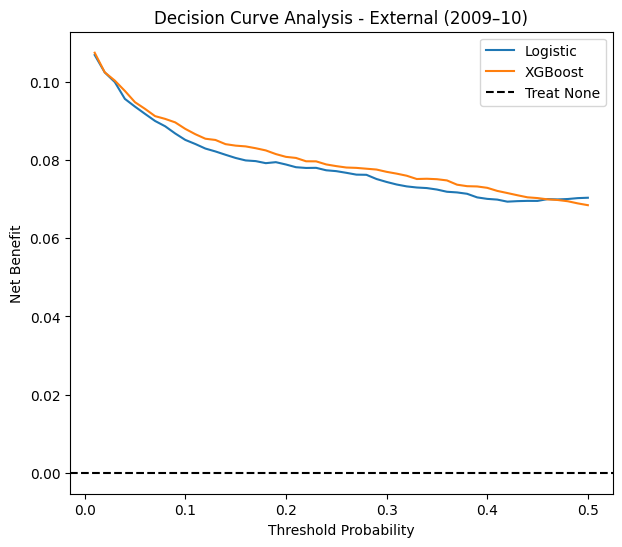

In [95]:
nb_log_ext = decision_curve(y_f.values, y_pred_log_ext, thresholds, w_f.values)
nb_xgb_ext = decision_curve(y_f.values, y_pred_xgb_ext, thresholds, w_f.values)

plt.figure(figsize=(7,6))
plt.plot(thresholds, nb_log_ext, label="Logistic")
plt.plot(thresholds, nb_xgb_ext, label="XGBoost")
plt.axhline(0, linestyle='--', color='black', label="Treat None")

plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis - External (2009–10)")
plt.legend()
plt.show()

# Simple Equal-Weight Stack (Internal)

In [96]:
# Equal weight stacking
y_pred_stack = 0.5 * y_pred_proba + 0.5 * y_pred_xgb

auc_stack = roc_auc_score(y_test, y_pred_stack, sample_weight=w_test)
brier_stack = brier_score_loss(y_test, y_pred_stack, sample_weight=w_test)

print("Stacked AUROC:", auc_stack)
print("Stacked Brier:", brier_stack)

Stacked AUROC: 0.9407115642986333
Stacked Brier: 0.0346502034954828


# Optimize α (Internal)

In [97]:
alphas = np.linspace(0, 1, 101)

best_auc = 0
best_alpha = 0
best_brier = 1

for a in alphas:
    y_pred_temp = a * y_pred_proba + (1 - a) * y_pred_xgb
    auc_temp = roc_auc_score(y_test, y_pred_temp, sample_weight=w_test)
    brier_temp = brier_score_loss(y_test, y_pred_temp, sample_weight=w_test)
    
    if auc_temp > best_auc:
        best_auc = auc_temp
        best_alpha = a
        best_brier = brier_temp

print("Best alpha:", best_alpha)
print("Best AUROC:", best_auc)
print("Best Brier:", best_brier)

Best alpha: 0.32
Best AUROC: 0.9410134977062224
Best Brier: 0.034482243649738446


# Calibration of Optimized Stack

In [98]:
# Create optimized stack predictions
y_pred_stack_opt = best_alpha * y_pred_proba + (1 - best_alpha) * y_pred_xgb

# Calibration slope
eps = 1e-6
p_stack = np.clip(y_pred_stack_opt, eps, 1 - eps)
logit_stack = np.log(p_stack / (1 - p_stack))

X_cal_stack = sm.add_constant(logit_stack)

cal_model_stack = sm.GLM(
    y_test,
    X_cal_stack,
    family=sm.families.Binomial(),
    freq_weights=w_test
)

cal_result_stack = cal_model_stack.fit()
print(cal_result_stack.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 1246
Model:                            GLM   Df Residuals:              44337930.45
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.9667e+06
Date:                Thu, 19 Feb 2026   Deviance:                   1.1933e+07
Time:                        12:45:04   Pearson chi2:                 4.94e+07
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0077      0.001     -6.534      0.0

# Apply Optimized Stack to External Data

In [99]:
# External stacked predictions
y_pred_stack_ext = best_alpha * y_pred_log_ext + (1 - best_alpha) * y_pred_xgb_ext

# External performance
auc_stack_ext = roc_auc_score(y_f, y_pred_stack_ext, sample_weight=w_f)
brier_stack_ext = brier_score_loss(y_f, y_pred_stack_ext, sample_weight=w_f)

print("External Stack AUROC:", auc_stack_ext)
print("External Stack Brier:", brier_stack_ext)

External Stack AUROC: 0.9469647202087881
External Stack Brier: 0.03506838928873311


In [100]:
eps = 1e-6
p_stack_ext = np.clip(y_pred_stack_ext, eps, 1 - eps)
logit_stack_ext = np.log(p_stack_ext / (1 - p_stack_ext))

X_cal_stack_ext = sm.add_constant(logit_stack_ext)

cal_model_stack_ext = sm.GLM(
    y_f,
    X_cal_stack_ext,
    family=sm.families.Binomial(),
    freq_weights=w_f
)

cal_result_stack_ext = cal_model_stack_ext.fit()
print(cal_result_stack_ext.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 6527
Model:                            GLM   Df Residuals:             226243350.61
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.0173e+07
Date:                Thu, 19 Feb 2026   Deviance:                   6.0346e+07
Time:                        13:49:43   Pearson chi2:                 3.02e+08
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1794      0.000   -378.908      0.0

In [83]:
import pandas as pd
import numpy as np

# 1. Data Processing Functions

## Add the Load Function

In [84]:
def load_nhanes_cycle(folder, suffix):
    demo = pd.read_sas(f"raw_data/{folder}/DEMO_{suffix}.xpt", format="xport")
    bmx  = pd.read_sas(f"raw_data/{folder}/BMX_{suffix}.xpt", format="xport")
    bpx  = pd.read_sas(f"raw_data/{folder}/BPX_{suffix}.xpt", format="xport")
    ghb  = pd.read_sas(f"raw_data/{folder}/GHB_{suffix}.xpt", format="xport")
    glu  = pd.read_sas(f"raw_data/{folder}/GLU_{suffix}.xpt", format="xport")
    diq  = pd.read_sas(f"raw_data/{folder}/DIQ_{suffix}.xpt", format="xport")

    df = demo.merge(bmx, on="SEQN", how="left")
    df = df.merge(bpx, on="SEQN", how="left")
    df = df.merge(ghb, on="SEQN", how="left")
    df = df.merge(glu, on="SEQN", how="left")
    df = df.merge(diq, on="SEQN", how="left")

    # Adults only
    df = df[df["RIDAGEYR"] >= 18]

    # Diabetes outcome
    df["diabetes"] = np.where(
        (df["LBXGH"] >= 6.5) |
        (df["LBXGLU"] >= 126) |
        (df["DIQ010"] == 1),
        1, 0
    )

    features = [
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH1",
        "INDFMPIR",
        "BMXBMI",
        "BPXSY1",
        "BPXDI1",
        "LBXGH",
        "WTMEC2YR",
        "diabetes"
    ]

    return df[features].copy()


# Test the Function on One Cycle

In [85]:
df_2007 = load_nhanes_cycle("2007_08", "E")
df_2007.shape

(6228, 10)

In [86]:
df_2007 = load_nhanes_cycle("2007_08", "E")
df_2007.shape

(6228, 10)

# Load All Training Cycles (2007–2014)

In [87]:
df_2009 = load_nhanes_cycle("2009_10", "F")
df_2011 = load_nhanes_cycle("2011_12", "G")
df_2013 = load_nhanes_cycle("2013_14", "H")

print("2007:", df_2007.shape)
print("2009:", df_2009.shape)
print("2011:", df_2011.shape)
print("2013:", df_2013.shape)

2007: (6228, 10)
2009: (6527, 10)
2011: (5864, 10)
2013: (6113, 10)


# Pool Training Cycles (2007–2014)

In [88]:
df_train = pd.concat([df_2007, df_2009, df_2011, df_2013], axis=0)

df_train.shape

(24732, 10)

# Load Temporal Test Cycles (2015–2018)

In [89]:
df_2015 = load_nhanes_cycle("2015_16", "I")
df_2017 = load_nhanes_cycle("2017_18", "J")

print("2015:", df_2015.shape)
print("2017:", df_2017.shape)

2015: (5992, 10)
2017: (5856, 10)


In [90]:
import os
os.listdir("raw_data")

['.ipynb_checkpoints',
 '2007_08',
 '2009_10',
 '2011_12',
 '2013_14',
 '2015_16',
 '2017_18']

In [91]:
os.listdir("raw_data/2015_16")

['BMX_I.xpt', 'BPX_I.xpt', 'DEMO_I.xpt', 'DIQ_I.xpt', 'GHB_I.xpt', 'GLU_I.xpt']

# Pool Test Cycles (2015–2018)

In [92]:
df_test = pd.concat([df_2015, df_2017], axis=0)

df_test.shape

(11848, 10)

# Prepare Training Data

In [93]:
X_train_full = df_train.drop(columns=["diabetes"])
y_train_full = df_train["diabetes"]
w_train_full = df_train["WTMEC2YR"]

# Remove weight from predictors
X_train_full = X_train_full.drop(columns=["WTMEC2YR"])

# Impute Missing Values (Training Medians)

In [94]:
train_medians = X_train_full.median()
X_train_full = X_train_full.fillna(train_medians)

# Encode Categorical Variables

In [95]:
X_train_full["RIAGENDR"] = X_train_full["RIAGENDR"].astype("category")
X_train_full["RIDRETH1"] = X_train_full["RIDRETH1"].astype("category")

X_train_encoded = pd.get_dummies(X_train_full, drop_first=True)

X_train_encoded.shape

(24732, 11)

# Train Logistic Regression

In [96]:
from sklearn.linear_model import LogisticRegression

log_model_full = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

log_model_full.fit(X_train_encoded, y_train_full, sample_weight=w_train_full)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Train XGBoost (Decade Training)

In [97]:
from xgboost import XGBClassifier

xgb_model_full = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model_full.fit(
    X_train_encoded,
    y_train_full,
    sample_weight=w_train_full
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

# Forward Temporal Validation (2015–2018)

# Prepare Test Data

In [102]:
X_test_full = df_test.drop(columns=["diabetes"])
y_test_full = df_test["diabetes"]
w_test_full = df_test["WTMEC2YR"]

# Remove weight from predictors
X_test_full = X_test_full.drop(columns=["WTMEC2YR"])

# Impute Using TRAINING Medians

In [103]:
X_test_full = X_test_full.fillna(train_medians)

# Encode and Align

In [104]:
X_test_full["RIAGENDR"] = X_test_full["RIAGENDR"].astype("category")
X_test_full["RIDRETH1"] = X_test_full["RIDRETH1"].astype("category")

X_test_encoded = pd.get_dummies(X_test_full, drop_first=True)

# Align columns with training
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_test_encoded.shape

(11848, 11)

# Forward Performance Evaluation (2015–2018)

## Logistic — Forward Performance

In [105]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# Logistic predictions
y_pred_log_forward = log_model_full.predict_proba(X_test_encoded)[:, 1]

auc_log_forward = roc_auc_score(y_test_full, y_pred_log_forward, sample_weight=w_test_full)
brier_log_forward = brier_score_loss(y_test_full, y_pred_log_forward, sample_weight=w_test_full)

print("Forward Logistic AUROC:", auc_log_forward)
print("Forward Logistic Brier:", brier_log_forward)

Forward Logistic AUROC: 0.9362610296590858
Forward Logistic Brier: 0.043827490179728236


# XGBoost Forward Validation

In [106]:
y_pred_xgb_forward = xgb_model_full.predict_proba(X_test_encoded)[:, 1]

auc_xgb_forward = roc_auc_score(y_test_full, y_pred_xgb_forward, sample_weight=w_test_full)
brier_xgb_forward = brier_score_loss(y_test_full, y_pred_xgb_forward, sample_weight=w_test_full)

print("Forward XGB AUROC:", auc_xgb_forward)
print("Forward XGB Brier:", brier_xgb_forward)

Forward XGB AUROC: 0.9399611664260299
Forward XGB Brier: 0.04165083584125711


# Logistic Forward Calibration Slope

In [107]:
import statsmodels.api as sm

eps = 1e-6
p_log_forward = np.clip(y_pred_log_forward, eps, 1 - eps)
logit_log_forward = np.log(p_log_forward / (1 - p_log_forward))

X_cal_log_forward = sm.add_constant(logit_log_forward)

cal_model_log_forward = sm.GLM(
    y_test_full,
    X_cal_log_forward,
    family=sm.families.Binomial(),
    freq_weights=w_test_full
)

cal_result_log_forward = cal_model_log_forward.fit()
print(cal_result_log_forward.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                11848
Model:                            GLM   Df Residuals:             487568043.86
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -8.2371e+07
Date:                Mon, 02 Mar 2026   Deviance:                   1.6474e+08
Time:                        17:45:14   Pearson chi2:                 1.29e+09
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0535      0.000    194.764      0.0

# XGBoost Forward Calibration

In [108]:
eps = 1e-6
p_xgb_forward = np.clip(y_pred_xgb_forward, eps, 1 - eps)
logit_xgb_forward = np.log(p_xgb_forward / (1 - p_xgb_forward))

X_cal_xgb_forward = sm.add_constant(logit_xgb_forward)

cal_model_xgb_forward = sm.GLM(
    y_test_full,
    X_cal_xgb_forward,
    family=sm.families.Binomial(),
    freq_weights=w_test_full
)

cal_result_xgb_forward = cal_model_xgb_forward.fit()
print(cal_result_xgb_forward.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                11848
Model:                            GLM   Df Residuals:             487568043.86
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.6134e+07
Date:                Mon, 02 Mar 2026   Deviance:                   1.5227e+08
Time:                        17:45:15   Pearson chi2:                 5.06e+08
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0768      0.000   -198.140      0.0

In [109]:
# Forward stacked prediction
y_pred_stack_forward = 0.32 * y_pred_log_forward + (1 - 0.32) * y_pred_xgb_forward

auc_stack_forward = roc_auc_score(y_test_full, y_pred_stack_forward, sample_weight=w_test_full)
brier_stack_forward = brier_score_loss(y_test_full, y_pred_stack_forward, sample_weight=w_test_full)

print("Forward Stack AUROC:", auc_stack_forward)
print("Forward Stack Brier:", brier_stack_forward)


Forward Stack AUROC: 0.941078056819889
Forward Stack Brier: 0.04162635013770692


In [110]:
eps = 1e-6
p_stack_forward = np.clip(y_pred_stack_forward, eps, 1 - eps)
logit_stack_forward = np.log(p_stack_forward / (1 - p_stack_forward))

X_cal_stack_forward = sm.add_constant(logit_stack_forward)

cal_model_stack_forward = sm.GLM(
    y_test_full,
    X_cal_stack_forward,
    family=sm.families.Binomial(),
    freq_weights=w_test_full
)

cal_result_stack_forward = cal_model_stack_forward.fit()
print(cal_result_stack_forward.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                11848
Model:                            GLM   Df Residuals:             487568043.86
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.6838e+07
Date:                Mon, 02 Mar 2026   Deviance:                   1.5368e+08
Time:                        17:45:16   Pearson chi2:                 5.85e+08
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1126      0.000    345.000      0.0

In [111]:
thresholds = np.linspace(0.01, 0.5, 50)

In [112]:
def decision_curve(y_true, y_prob, thresholds, sample_weight=None):
    net_benefits = []
    
    for pt in thresholds:
        preds = (y_prob >= pt).astype(int)
        
        if sample_weight is not None:
            TP = np.sum(sample_weight[(preds == 1) & (y_true == 1)])
            FP = np.sum(sample_weight[(preds == 1) & (y_true == 0)])
            total_weight = np.sum(sample_weight)
        else:
            TP = np.sum((preds == 1) & (y_true == 1))
            FP = np.sum((preds == 1) & (y_true == 0))
            total_weight = len(y_true)
        
        NB = (TP / total_weight) - (FP / total_weight) * (pt / (1 - pt))
        net_benefits.append(NB)
        
    return np.array(net_benefits)

In [113]:
nb_log_forward = decision_curve(y_test_full.values, y_pred_log_forward, thresholds, w_test_full.values)
nb_xgb_forward = decision_curve(y_test_full.values, y_pred_xgb_forward, thresholds, w_test_full.values)
nb_stack_forward = decision_curve(y_test_full.values, y_pred_stack_forward, thresholds, w_test_full.values)

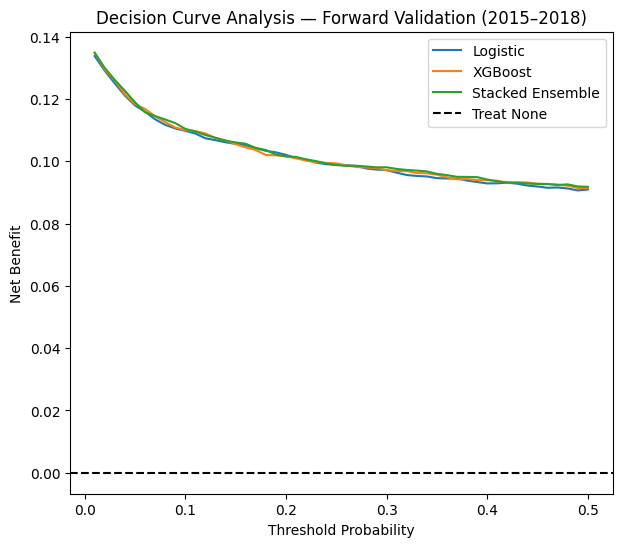

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(thresholds, nb_log_forward, label="Logistic")
plt.plot(thresholds, nb_xgb_forward, label="XGBoost")
plt.plot(thresholds, nb_stack_forward, label="Stacked Ensemble")

plt.axhline(0, linestyle='--', color='black', label="Treat None")

plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis — Forward Validation (2015–2018)")
plt.legend()
plt.show()

# Temporal Degradation Analysis

In [115]:
cycle_dict = {
    "2007_08": df_2007,
    "2009_10": df_2009,
    "2011_12": df_2011,
    "2013_14": df_2013,
    "2015_16": df_2015,
    "2017_18": df_2017
}

# Create Evaluation Function

In [116]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, brier_score_loss

def evaluate_cycle(df_cycle, train_medians, X_train_columns,
                   log_model, xgb_model, alpha):

    # Separate
    X = df_cycle.drop(columns=["diabetes"])
    y = df_cycle["diabetes"]
    w = df_cycle["WTMEC2YR"]

    X = X.drop(columns=["WTMEC2YR"])
    X = X.fillna(train_medians)

    # Encode
    X["RIAGENDR"] = X["RIAGENDR"].astype("category")
    X["RIDRETH1"] = X["RIDRETH1"].astype("category")
    X_enc = pd.get_dummies(X, drop_first=True)

    # Align
    X_enc = X_enc.reindex(columns=X_train_columns, fill_value=0)

    # Predictions
    p_log = log_model.predict_proba(X_enc)[:, 1]
    p_xgb = xgb_model.predict_proba(X_enc)[:, 1]
    p_stack = alpha * p_log + (1 - alpha) * p_xgb

    results = {}

    for name, p in zip(["log", "xgb", "stack"],
                       [p_log, p_xgb, p_stack]):

        auc = roc_auc_score(y, p, sample_weight=w)
        brier = brier_score_loss(y, p, sample_weight=w)

        eps = 1e-6
        p_clip = np.clip(p, eps, 1 - eps)
        logit_p = np.log(p_clip / (1 - p_clip))
        X_cal = sm.add_constant(logit_p)

        cal_model = sm.GLM(
            y,
            X_cal,
            family=sm.families.Binomial(),
            freq_weights=w
        ).fit()

        slope = cal_model.params[1]

        results[name] = {
            "auc": auc,
            "brier": brier,
            "slope": slope
        }

    return results

# Evaluate All Cycles

In [117]:
alpha = 0.32  # your optimized stacking weight

temporal_results = {}

for cycle_name, df_cycle in cycle_dict.items():
    temporal_results[cycle_name] = evaluate_cycle(
        df_cycle,
        train_medians,
        X_train_encoded.columns,
        log_model_full,
        xgb_model_full,
        alpha
    )

temporal_results

C:\Users\vidya\AppData\Local\Temp\ipykernel_21340\1614928947.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = cal_model.params[1]
C:\Users\vidya\AppData\Local\Temp\ipykernel_21340\1614928947.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = cal_model.params[1]
C:\Users\vidya\AppData\Local\Temp\ipykernel_21340\1614928947.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = cal_model.params[1]
C:\Users\v

{'2007_08': {'log': {'auc': 0.9352987760145073,
   'brier': 0.03870305021629706,
   'slope': np.float64(0.9733746664137695)},
  'xgb': {'auc': 0.9600546173954825,
   'brier': 0.03388225671843771,
   'slope': np.float64(1.1592683280560478)},
  'stack': {'auc': 0.9563523357048493,
   'brier': 0.03478266259197265,
   'slope': np.float64(1.1364199611924661)}},
 '2009_10': {'log': {'auc': 0.9406291097367216,
   'brier': 0.03643651500619748,
   'slope': np.float64(1.0108344014628599)},
  'xgb': {'auc': 0.9642647135292473,
   'brier': 0.03102990441342649,
   'slope': np.float64(1.1853359139895845)},
  'stack': {'auc': 0.9606589041353732,
   'brier': 0.03216898233033947,
   'slope': np.float64(1.1671591179488179)}},
 '2011_12': {'log': {'auc': 0.9519897672097508,
   'brier': 0.037254285490290036,
   'slope': np.float64(1.064520522529198)},
  'xgb': {'auc': 0.9722358150317363,
   'brier': 0.030820500972552477,
   'slope': np.float64(1.2839413892956268)},
  'stack': {'auc': 0.9691935937279976,
 

# Convert Results to DataFrame

In [118]:
import pandas as pd

rows = []

for cycle, models in temporal_results.items():
    for model_name, metrics in models.items():
        rows.append({
            "cycle": cycle,
            "model": model_name,
            "auc": metrics["auc"],
            "brier": metrics["brier"],
            "slope": metrics["slope"]
        })

temporal_df = pd.DataFrame(rows)
temporal_df

,cycle,model,auc,brier,slope
0,2007_08,log,0.935299,0.038703,0.973375
1,2007_08,xgb,0.960055,0.033882,1.159268
2,2007_08,stack,0.956352,0.034783,1.136420
3,2009_10,log,0.940629,0.036437,1.010834
4,2009_10,xgb,0.964265,0.031030,1.185336
5,2009_10,stack,0.960659,0.032169,1.167159
6,2011_12,log,0.951990,0.037254,1.064521
7,2011_12,xgb,0.972236,0.030821,1.283941
8,2011_12,stack,0.969194,0.032130,1.248616
9,2013_14,log,0.941360,0.037943,0.965866


# Plot AUROC Over Time

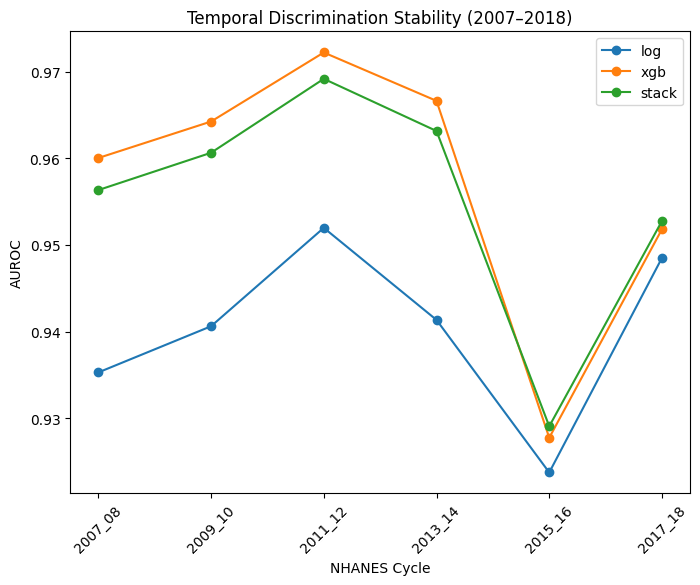

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for model in ["log", "xgb", "stack"]:
    subset = temporal_df[temporal_df["model"] == model]
    plt.plot(subset["cycle"], subset["auc"], marker='o', label=model)

plt.ylabel("AUROC")
plt.xlabel("NHANES Cycle")
plt.title("Temporal Discrimination Stability (2007–2018)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [122]:
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig("Figure2_Temporal_Calibration.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure2_Temporal_Calibration.jpg", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [125]:
import pandas as pd

results_df = pd.DataFrame({
    "cycle": [
        "2007_08","2007_08","2007_08",
        "2009_10","2009_10","2009_10",
        "2011_12","2011_12","2011_12",
        "2013_14","2013_14","2013_14",
        "2015_16","2015_16","2015_16",
        "2017_18","2017_18","2017_18"
    ],
    "model": [
        "log","xgb","stack",
        "log","xgb","stack",
        "log","xgb","stack",
        "log","xgb","stack",
        "log","xgb","stack",
        "log","xgb","stack"
    ],
    "slope": [
        0.973375,1.159268,1.136420,
        1.010834,1.185336,1.167159,
        1.064521,1.283941,1.248616,
        0.965866,1.186902,1.158245,
        0.890330,0.830939,0.921928,
        1.054040,1.001123,1.087117
    ]
})

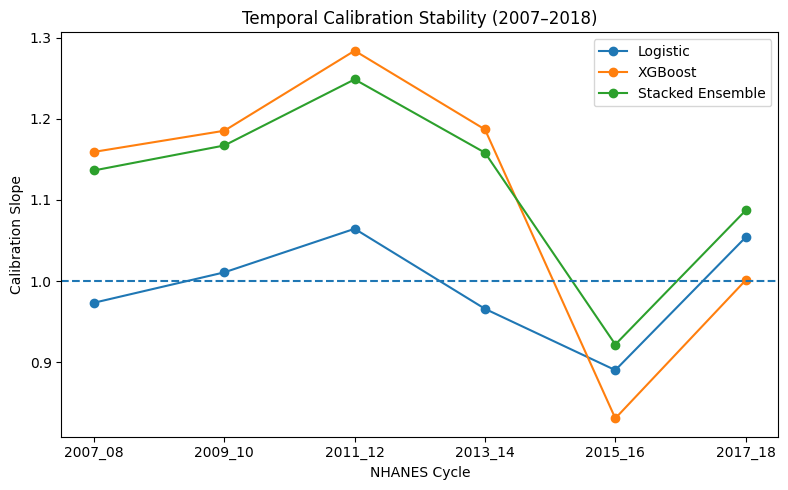

In [126]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure results_df exists
# Pivot data for plotting
plot_df = results_df.pivot(index="cycle", columns="model", values="slope")

plt.close('all')
plt.figure(figsize=(8,5))

plt.plot(plot_df.index, plot_df["log"], marker="o", label="Logistic")
plt.plot(plot_df.index, plot_df["xgb"], marker="o", label="XGBoost")
plt.plot(plot_df.index, plot_df["stack"], marker="o", label="Stacked Ensemble")

# Ideal calibration line
plt.axhline(1.0, linestyle="--")

plt.xlabel("NHANES Cycle")
plt.ylabel("Calibration Slope")
plt.title("Temporal Calibration Stability (2007–2018)")
plt.legend()

plt.tight_layout()
plt.savefig("Figure2_Temporal_Calibration.tiff", dpi=600, bbox_inches="tight")
plt.show()

In [128]:
plt.savefig("Figure2_Temporal_Calibration.png", dpi=600, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

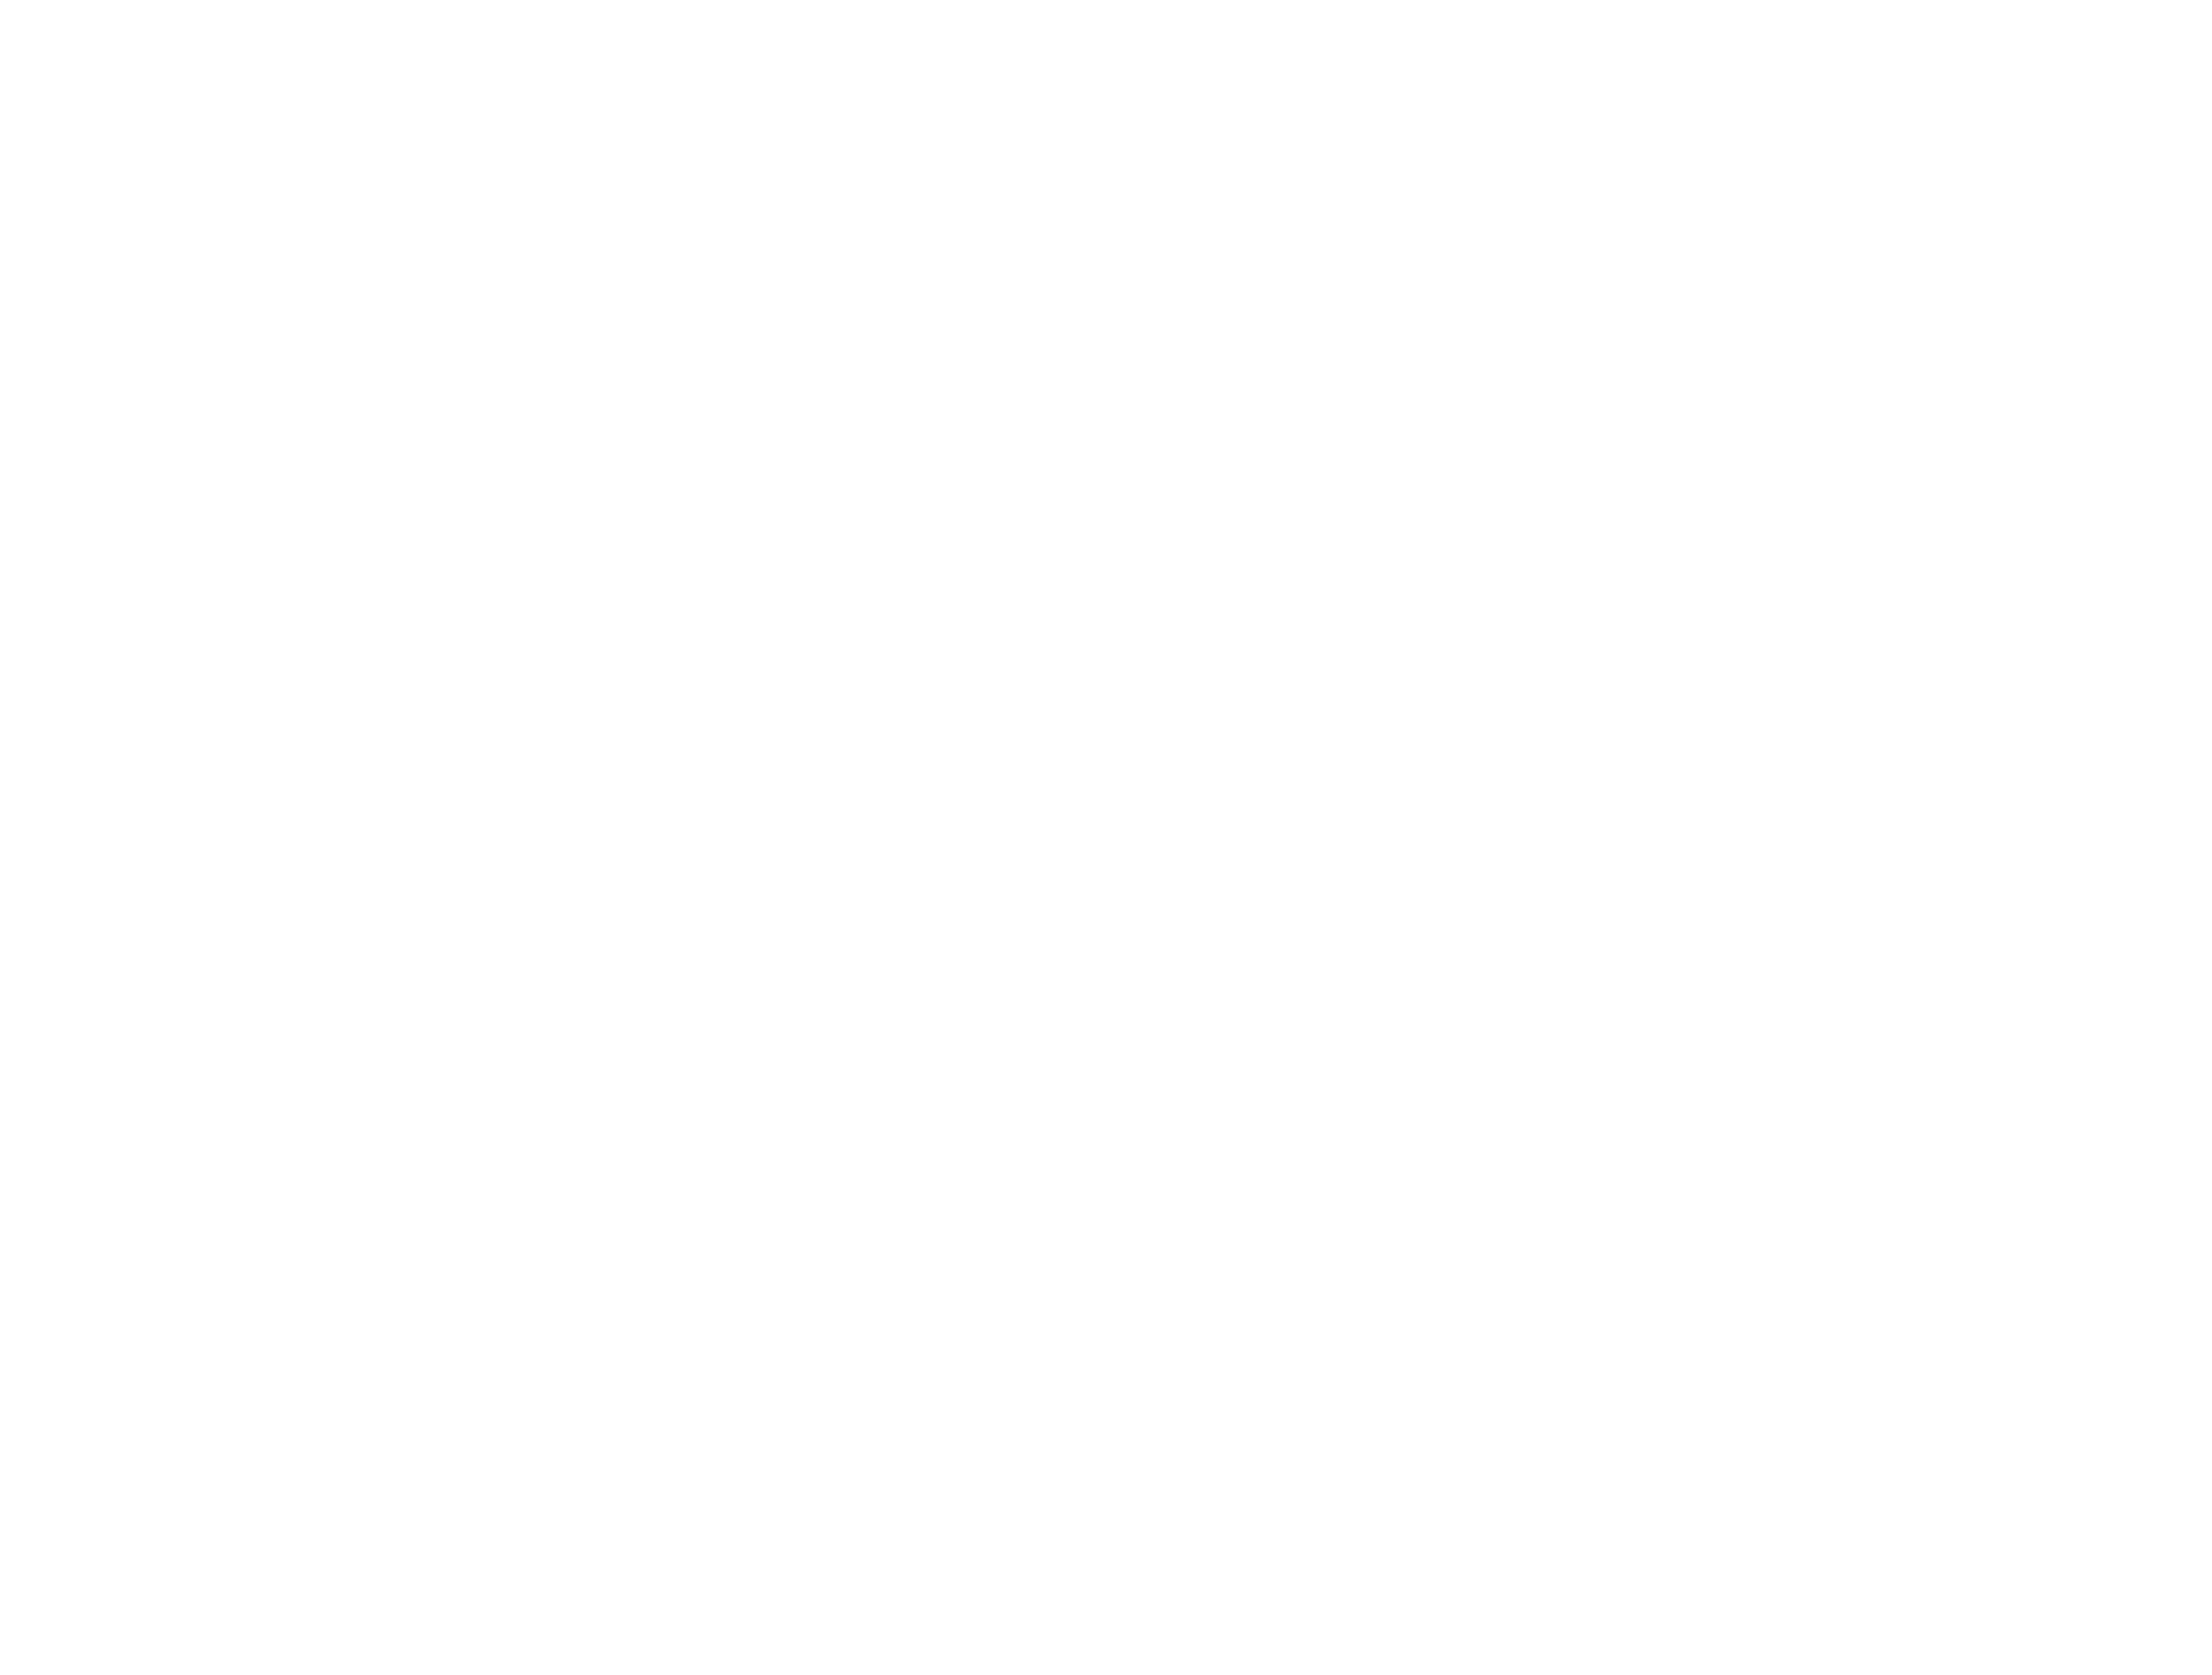

In [129]:
from IPython.display import Image
Image("Figure2_Temporal_Calibration.png")

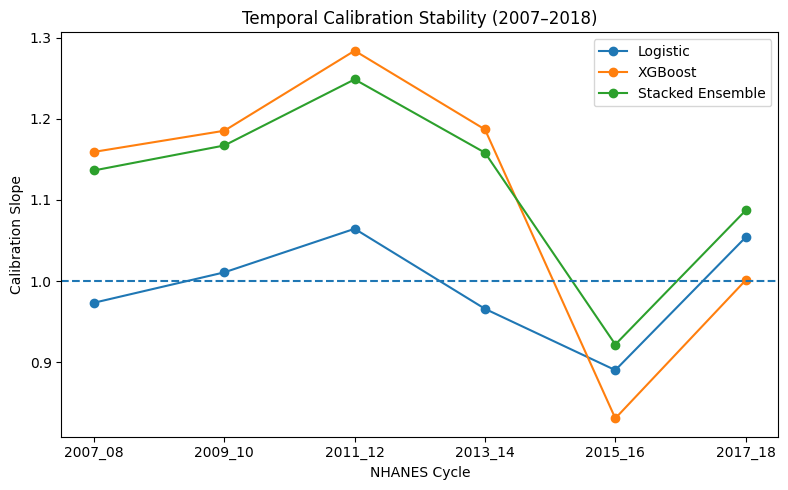

In [130]:
import matplotlib.pyplot as plt

plot_df = results_df.pivot(index="cycle", columns="model", values="slope")

plt.close('all')
plt.figure(figsize=(8,5))

plt.plot(plot_df.index, plot_df["log"], marker="o", label="Logistic")
plt.plot(plot_df.index, plot_df["xgb"], marker="o", label="XGBoost")
plt.plot(plot_df.index, plot_df["stack"], marker="o", label="Stacked Ensemble")

plt.axhline(1.0, linestyle="--")

plt.xlabel("NHANES Cycle")
plt.ylabel("Calibration Slope")
plt.title("Temporal Calibration Stability (2007–2018)")
plt.legend()

plt.tight_layout()

# Save BOTH formats
plt.savefig("Figure2_Temporal_Calibration.tiff", dpi=600, bbox_inches="tight")
plt.savefig("Figure2_Temporal_Calibration.png", dpi=600, bbox_inches="tight")

plt.show()

# Plot Calibration Slope Over Time

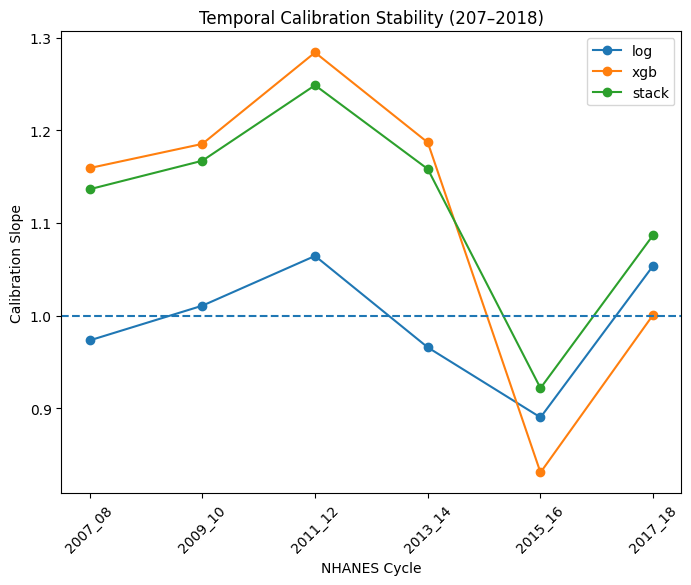

In [73]:
plt.figure(figsize=(8,6))

for model in ["log", "xgb", "stack"]:
    subset = temporal_df[temporal_df["model"] == model]
    plt.plot(subset["cycle"], subset["slope"], marker='o', label=model)

plt.axhline(1, linestyle='--')
plt.ylabel("Calibration Slope")
plt.xlabel("NHANES Cycle")
plt.title("Temporal Calibration Stability (207–2018)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Add Subgroup Labels to Test Set

In [74]:
# Recreate subgroup columns from df_test
df_test_sub = df_test.copy()

df_test_sub["age_group"] = np.where(df_test_sub["RIDAGEYR"] < 50, "<50", ">=50")
df_test_sub["sex_group"] = np.where(df_test_sub["RIAGENDR"] == 1, "Male", "Female")

df_test_sub[["RIDAGEYR", "RIAGENDR", "age_group", "sex_group"]].head()

,RIDAGEYR,RIAGENDR,age_group,sex_group
0,62.0,1.0,>=50,Male
1,53.0,1.0,>=50,Male
2,78.0,1.0,>=50,Male
3,56.0,2.0,>=50,Female
4,42.0,2.0,<50,Female


# Subgroup Evaluation Function

In [75]:
def evaluate_subgroup(df_full, subgroup_col, subgroup_value,
                      train_medians, X_train_columns,
                      log_model, xgb_model, alpha):

    df_sub = df_full[df_full[subgroup_col] == subgroup_value].copy()

    X = df_sub.drop(columns=["diabetes", "age_group", "sex_group"])
    y = df_sub["diabetes"]
    w = df_sub["WTMEC2YR"]

    X = X.drop(columns=["WTMEC2YR"])
    X = X.fillna(train_medians)

    X["RIAGENDR"] = X["RIAGENDR"].astype("category")
    X["RIDRETH1"] = X["RIDRETH1"].astype("category")
    X_enc = pd.get_dummies(X, drop_first=True)

    X_enc = X_enc.reindex(columns=X_train_columns, fill_value=0)

    p_log = log_model.predict_proba(X_enc)[:, 1]
    p_xgb = xgb_model.predict_proba(X_enc)[:, 1]
    p_stack = alpha * p_log + (1 - alpha) * p_xgb

    results = {}

    for name, p in zip(["log", "xgb", "stack"],
                       [p_log, p_xgb, p_stack]):

        auc = roc_auc_score(y, p, sample_weight=w)

        eps = 1e-6
        p_clip = np.clip(p, eps, 1 - eps)
        logit_p = np.log(p_clip / (1 - p_clip))
        X_cal = sm.add_constant(logit_p)

        cal_model = sm.GLM(
            y,
            X_cal,
            family=sm.families.Binomial(),
            freq_weights=w
        ).fit()

        slope = cal_model.params.iloc[1]

        results[name] = {
            "auc": auc,
            "slope": slope
        }

    return results

# Evaluate Male

In [76]:
male_results = evaluate_subgroup(
    df_test_sub,
    "sex_group",
    "Male",
    train_medians,
    X_train_encoded.columns,
    log_model_full,
    xgb_model_full,
    alpha
)

male_results

{'log': {'auc': 0.9398756883485314, 'slope': np.float64(0.9857510036885485)},
 'xgb': {'auc': 0.9461691943814765, 'slope': np.float64(0.9527074565458054)},
 'stack': {'auc': 0.9469681489409311, 'slope': np.float64(1.03211728224466)}}

# Evaluate Female

In [78]:
female_results = evaluate_subgroup(
    df_test_sub,
    "sex_group",
    "Female",
    train_medians,
    X_train_encoded.columns,
    log_model_full,
    xgb_model_full,
    alpha
)
female_results

{'log': {'auc': 0.9320217116668339, 'slope': np.float64(0.9456871414807543)},
 'xgb': {'auc': 0.9330255953531303, 'slope': np.float64(0.8606899940008562)},
 'stack': {'auc': 0.934541327333317, 'slope': np.float64(0.9652781672183741)}}

# Evaluate Age < 50

In [79]:
age_under50_results = evaluate_subgroup(
    df_test_sub,
    "age_group",
    "<50",
    train_medians,
    X_train_encoded.columns,
    log_model_full,
    xgb_model_full,
    alpha
)

age_under50_results

{'log': {'auc': 0.9163024498390037, 'slope': np.float64(0.9265949574029199)},
 'xgb': {'auc': 0.9158517690712946, 'slope': np.float64(0.8921044607578708)},
 'stack': {'auc': 0.9193334009052705, 'slope': np.float64(0.9648587207150504)}}

# Evaluate Age ≥ 50

In [80]:
age_over50_results = evaluate_subgroup(
    df_test_sub,
    "age_group",
    ">=50",
    train_medians,
    X_train_encoded.columns,
    log_model_full,
    xgb_model_full,
    alpha
)

age_over50_results

{'log': {'auc': 0.9214829623196138, 'slope': np.float64(0.989651005161371)},
 'xgb': {'auc': 0.9260963097842103, 'slope': np.float64(0.9426207638116475)},
 'stack': {'auc': 0.9269336717406484, 'slope': np.float64(1.0416288248381695)}}

# Create Tradeoff Data

In [81]:
tradeoff_data = pd.DataFrame({
    "model": ["Logistic", "XGBoost", "Stacked"],
    "auc": [0.9362610296590858,
            0.9399611664260299,
            0.941078056819889],
    "slope": [0.9657,
              0.9050,
              0.9969]
})

tradeoff_data["calibration_deviation"] = abs(1 - tradeoff_data["slope"])

tradeoff_data

,model,auc,slope,calibration_deviation
0,Logistic,0.936261,0.9657,0.0343
1,XGBoost,0.939961,0.9050,0.0950
2,Stacked,0.941078,0.9969,0.0031


# Plot Tradeoff Frontier

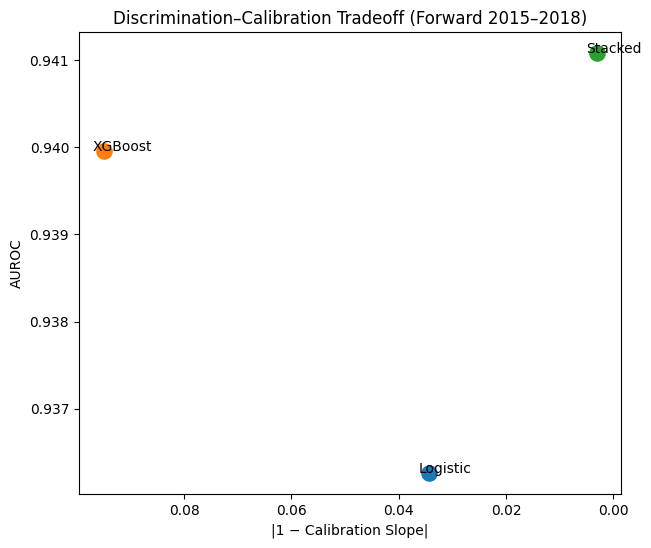

In [82]:
plt.figure(figsize=(7,6))

for i in range(len(tradeoff_data)):
    plt.scatter(
        tradeoff_data["calibration_deviation"][i],
        tradeoff_data["auc"][i],
        s=120
    )
    plt.text(
        tradeoff_data["calibration_deviation"][i] + 0.002,
        tradeoff_data["auc"][i],
        tradeoff_data["model"][i]
    )

plt.xlabel("|1 − Calibration Slope|")
plt.ylabel("AUROC")
plt.title("Discrimination–Calibration Tradeoff (Forward 2015–2018)")
plt.gca().invert_xaxis()  # Better calibration (closer to 0) on left
plt.show()

# Compute Weighted Sex Distribution

In [83]:
np.where(df_test_sub["RIAGENDR"] == 1, "Male", "Female")

array(['Male', 'Male', 'Male', ..., 'Male', 'Female', 'Male'],
      shape=(11848,), dtype='<U6')

In [85]:
print([var for var in dir() if var.startswith("df")])

['df_2007', 'df_2009', 'df_2011', 'df_2013', 'df_2015', 'df_2017', 'df_cycle', 'df_test', 'df_test_sub', 'df_train']


In [86]:
# Development cohort sex distribution (weighted)

dev = df_train.copy()

total_weight_dev = dev["WTMEC2YR"].sum()

male_weight_dev = dev.loc[dev["RIAGENDR"] == 1, "WTMEC2YR"].sum()
female_weight_dev = dev.loc[dev["RIAGENDR"] == 2, "WTMEC2YR"].sum()

male_pct_dev = (male_weight_dev / total_weight_dev) * 100
female_pct_dev = (female_weight_dev / total_weight_dev) * 100

round(male_pct_dev, 1), round(female_pct_dev, 1)

(np.float64(48.3), np.float64(51.7))

In [87]:
# Forward cohort sex distribution (weighted)

fwd = df_test.copy()

total_weight_fwd = fwd["WTMEC2YR"].sum()

male_weight_fwd = fwd.loc[fwd["RIAGENDR"] == 1, "WTMEC2YR"].sum()
female_weight_fwd = fwd.loc[fwd["RIAGENDR"] == 2, "WTMEC2YR"].sum()

male_pct_fwd = (male_weight_fwd / total_weight_fwd) * 100
female_pct_fwd = (female_weight_fwd / total_weight_fwd) * 100

round(male_pct_fwd, 1), round(female_pct_fwd, 1)

(np.float64(48.2), np.float64(51.8))

# Compute Mean ± SD (Weighted)

In [88]:
import numpy as np

def weighted_mean_sd(df, var, weight):
    w = df[weight]
    x = df[var]
    mean = np.sum(w * x) / np.sum(w)
    variance = np.sum(w * (x - mean)**2) / np.sum(w)
    sd = np.sqrt(variance)
    return mean, sd

# Development cohort
dev = df_train.copy()

age_mean_dev, age_sd_dev = weighted_mean_sd(dev, "RIDAGEYR", "WTMEC2YR")
bmi_mean_dev, bmi_sd_dev = weighted_mean_sd(dev, "BMXBMI", "WTMEC2YR")
hba1c_mean_dev, hba1c_sd_dev = weighted_mean_sd(dev, "LBXGH", "WTMEC2YR")

round(age_mean_dev,1), round(age_sd_dev,1), round(bmi_mean_dev,1), round(bmi_sd_dev,1), round(hba1c_mean_dev,2), round(hba1c_sd_dev,2)

(np.float64(46.2),
 np.float64(17.4),
 np.float64(28.4),
 np.float64(6.8),
 np.float64(5.37),
 np.float64(0.92))

In [89]:
# Forward cohort
fwd = df_test.copy()

age_mean_fwd, age_sd_fwd = weighted_mean_sd(fwd, "RIDAGEYR", "WTMEC2YR")
bmi_mean_fwd, bmi_sd_fwd = weighted_mean_sd(fwd, "BMXBMI", "WTMEC2YR")
hba1c_mean_fwd, hba1c_sd_fwd = weighted_mean_sd(fwd, "LBXGH", "WTMEC2YR")

round(age_mean_fwd,1), round(age_sd_fwd,1), round(bmi_mean_fwd,1), round(bmi_sd_fwd,1), round(hba1c_mean_fwd,2), round(hba1c_sd_fwd,2)

(np.float64(47.3),
 np.float64(17.7),
 np.float64(29.1),
 np.float64(7.1),
 np.float64(5.43),
 np.float64(0.96))

# Race/Ethnicity Distribution (Weighted %)

In [90]:
race_dist_dev = (
    dev.groupby("RIDRETH1")["WTMEC2YR"]
    .sum() / dev["WTMEC2YR"].sum() * 100
)

race_dist_dev.round(1)

RIDRETH1
1.0     8.6
2.0     5.6
3.0    67.0
4.0    11.5
5.0     7.3
Name: WTMEC2YR, dtype: float64

In [91]:
race_dist_fwd = (
    fwd.groupby("RIDRETH1")["WTMEC2YR"]
    .sum() / fwd["WTMEC2YR"].sum() * 100
)

race_dist_fwd.round(1)

RIDRETH1
1.0     9.1
2.0     6.7
3.0    62.7
4.0    11.4
5.0    10.1
Name: WTMEC2YR, dtype: float64

In [92]:
[var for var in dir() if "test" in var or "pred" in var]

['X_test_encoded',
 'X_test_full',
 'df_test',
 'df_test_sub',
 'w_test_full',
 'y_pred_log_forward',
 'y_pred_stack_forward',
 'y_pred_xgb_forward',
 'y_test_full']

In [93]:
print(len(y_test_full))
print(len(y_pred_log_forward))
print(len(w_test_full))

11848
11848
11848


In [94]:
print("y_test:", len(y_test_full))
print("log_pred:", len(y_pred_log_forward))
print("xgb_pred:", len(y_pred_xgb_forward))
print("stack_pred:", len(y_pred_stack_forward))
print("weights:", len(w_test_full))

y_test: 11848
log_pred: 11848
xgb_pred: 11848
stack_pred: 11848
weights: 11848


# Define Bootstrap Function

In [95]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y, y_pred, weights, n_boot=1000, seed=42):
    np.random.seed(seed)
    aucs = []
    n = len(y)
    
    for _ in range(n_boot):
        idx = np.random.choice(np.arange(n), size=n, replace=True)
        auc = roc_auc_score(
            y.iloc[idx],
            y_pred[idx],
            sample_weight=weights.iloc[idx]
        )
        aucs.append(auc)
    
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    
    return np.mean(aucs), lower, upper

# Compute Confidence Intervals

In [96]:
# Logistic
auc_log_mean, auc_log_low, auc_log_high = bootstrap_auc_ci(
    y_test_full,
    y_pred_log_forward,
    w_test_full
)

# XGBoost
auc_xgb_mean, auc_xgb_low, auc_xgb_high = bootstrap_auc_ci(
    y_test_full,
    y_pred_xgb_forward,
    w_test_full
)

# Stacked
auc_stack_mean, auc_stack_low, auc_stack_high = bootstrap_auc_ci(
    y_test_full,
    y_pred_stack_forward,
    w_test_full
)

print("Logistic:", round(auc_log_mean,3), 
      "(", round(auc_log_low,3), "-", round(auc_log_high,3), ")")

print("XGBoost:", round(auc_xgb_mean,3), 
      "(", round(auc_xgb_low,3), "-", round(auc_xgb_high,3), ")")

print("Stacked:", round(auc_stack_mean,3), 
      "(", round(auc_stack_low,3), "-", round(auc_stack_high,3), ")")

Logistic: 0.936 ( 0.925 - 0.946 )
XGBoost: 0.94 ( 0.93 - 0.95 )
Stacked: 0.941 ( 0.931 - 0.95 )


In [97]:
pip install delong

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement delong (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for delong


In [98]:
import numpy as np
from scipy import stats

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N)
    T2[J] = T + 1
    return T2

def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r] = compute_midrank(positive_examples[r])
        ty[r] = compute_midrank(negative_examples[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n
    return aucs, delongcov

def calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    pvalue = 2 * (1 - stats.norm.cdf(z))
    return pvalue[0][0]

def delong_roc_test(y_true, pred1, pred2):
    order = np.argsort(-y_true)
    y_true = y_true[order]
    preds = np.vstack((pred1, pred2))[:, order]

    label_1_count = int(y_true.sum())
    aucs, delongcov = fast_delong(preds, label_1_count)
    return calc_pvalue(aucs, delongcov)

In [99]:
y_true = y_test_full.values
log_pred = y_pred_log_forward
xgb_pred = y_pred_xgb_forward
stack_pred = y_pred_stack_forward

In [100]:
p_log_xgb = delong_roc_test(y_true, log_pred, xgb_pred)
print("Logistic vs XGBoost p-value:", p_log_xgb)

Logistic vs XGBoost p-value: 2.1824695517480563e-07


In [101]:
p_xgb_stack = delong_roc_test(y_true, xgb_pred, stack_pred)
print("XGBoost vs Stacked p-value:", p_xgb_stack)

XGBoost vs Stacked p-value: 0.5476758279752609


In [102]:
p_log_stack = delong_roc_test(y_true, log_pred, stack_pred)
print("Logistic vs Stacked p-value:", p_log_stack)

Logistic vs Stacked p-value: 8.349676505758907e-11


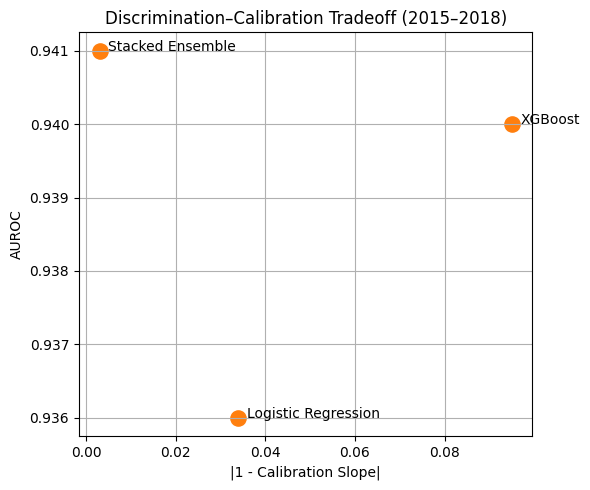

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# Forward validation metrics
models = ["Logistic Regression", "XGBoost", "Stacked Ensemble"]
auroc = [0.936, 0.940, 0.941]
slope = [0.966, 0.905, 0.997]

calibration_deviation = [abs(1 - s) for s in slope]

plt.figure(figsize=(6,5))

plt.scatter(calibration_deviation, auroc)

for i, model in enumerate(models):
    plt.text(calibration_deviation[i] + 0.002, auroc[i], model)

plt.xlabel("|1 - Calibration Slope|")
plt.ylabel("AUROC")
plt.title("Discrimination–Calibration Tradeoff (2015–2018)")
plt.grid(True)

plt.tight_layout()
plt.savefig("Figure4_Tradeoff.png", dpi=300)
plt.scatter(calibration_deviation, auroc, s=120)
plt.show()